# AIO Strategy Backtest: MACD MTF + Trendline Breaks + iFVG + ATR SL

Replica en Python la lógica del indicador/estrategia AIO de TradingView:
1. **MACD Multi-Timeframe** — Cruce de MACD/Señal
2. **Trendlines with Breaks** — Pivots + slope dinámico ATR → ruptura
3. **iFVG (Fair Value Gap)** — Detección de imbalances para entrada
4. **ATR Stop Loss Finder** — SL en `high + ATR*mult` / `low - ATR*mult`
5. **Confluencia** — TL break + MACD cross en ventana → Señal
6. **Backtest vectorizado** con métricas y gráficos

In [36]:
# ── Instalar dependencias si es necesario ──
# !pip install pandas numpy matplotlib ta MetaTrader5

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 1. Cargar datos
Puedes usar un CSV local o descargar directamente de MetaTrader 5.

In [38]:

# ═══════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL PAR Y TIMEFRAME
# ═══════════════════════════════════════════════════════════
SYMBOL  = 'USDJPY'
TF_NAME = 'M15'

# ═══════════════════════════════════════════════════════════
# CREDENCIALES MT5 (rellenar si el terminal no está logueado)
# ═══════════════════════════════════════════════════════════
MT5_LOGIN    = 0           # ← tu número de cuenta (int), 0 = usar sesión activa
MT5_PASSWORD = ''          # ← tu contraseña
MT5_SERVER   = ''          # ← nombre del servidor, ej: 'ICMarkets-Demo'
MT5_PATH     = ''          # ← ruta al terminal.exe si no está en la ubicación estándar

# ═══════════════════════════════════════════════════════════
# Descargar de MetaTrader 5
# ═══════════════════════════════════════════════════════════
import MetaTrader5 as mt5

tf_map = {
    'M1':  mt5.TIMEFRAME_M1,  'M5':  mt5.TIMEFRAME_M5,
    'M15': mt5.TIMEFRAME_M15, 'M30': mt5.TIMEFRAME_M30,
    'H1':  mt5.TIMEFRAME_H1,  'H4':  mt5.TIMEFRAME_H4,
    'D1':  mt5.TIMEFRAME_D1,
}
if TF_NAME not in tf_map:
    raise ValueError(f'TF_NAME "{TF_NAME}" no válido. Opciones: {list(tf_map)}')

# Construir kwargs de inicialización según lo que se haya rellenado
init_kwargs = {}
if MT5_PATH:
    init_kwargs['path'] = MT5_PATH
if MT5_LOGIN:
    init_kwargs['login']    = MT5_LOGIN
    init_kwargs['password'] = MT5_PASSWORD
    init_kwargs['server']   = MT5_SERVER

if not mt5.initialize(**init_kwargs):
    code, msg = mt5.last_error()
    raise RuntimeError(
        f'MT5 init failed ({code}): {msg}\n'
        f'  → Rellena MT5_LOGIN / MT5_PASSWORD / MT5_SERVER en esta celda, o\n'
        f'  → Abre MetaTrader 5 manualmente e inicia sesión antes de ejecutar.'
    )

# Verificar que el símbolo existe
info = mt5.symbol_info(SYMBOL)
if info is None:
    mt5.shutdown()
    raise RuntimeError(
        f'Símbolo "{SYMBOL}" no encontrado en MT5. '
        f'Verifica que está visible en el Market Watch.'
    )
if not info.visible:
    mt5.symbol_select(SYMBOL, True)   # activar en Market Watch

BARS  = 10000
rates = mt5.copy_rates_from_pos(SYMBOL, tf_map[TF_NAME], 0, BARS)
mt5.shutdown()

if rates is None or len(rates) == 0:
    raise RuntimeError(
        f'MT5 no devolvió datos para {SYMBOL} {TF_NAME}. '
        f'Verifica el símbolo y que el broker tiene histórico disponible.'
    )

df = pd.DataFrame(rates)
df['time'] = pd.to_datetime(df['time'], unit='s')
df.set_index('time', inplace=True)
df.rename(columns={'tick_volume': 'volume'}, inplace=True)
print(f'MT5 descargado: {len(df)} velas de {SYMBOL} {TF_NAME}')
print(f'  Rango: {df.index[0]}  →  {df.index[-1]}')

# Detectar si es par JPY (pip value distinto)
IS_JPY_PAIR = SYMBOL.endswith('JPY')
print(f'Par JPY: {IS_JPY_PAIR}')
df.head()


MT5 descargado: 10000 velas de USDJPY M15
  Rango: 2025-10-02 23:30:00  →  2026-03-02 04:00:00
Par JPY: True


,open,high,low,close,volume,spread,real_volume
time,,,,,,,
2025-10-02 23:30:00,147.234,147.251,147.209,147.249,194,5,0
2025-10-02 23:45:00,147.247,147.284,147.241,147.244,189,15,0
2025-10-03 00:00:00,147.179,147.222,147.179,147.218,3,64,0
2025-10-03 00:15:00,147.219,147.224,147.218,147.218,53,64,0
2025-10-03 00:30:00,147.216,147.220,147.204,147.208,68,64,0


## 2. Parámetros de la estrategia

In [ ]:
# ═══ MACD ═══
FAST_LEN   = 12
SLOW_LEN   = 26
SIGNAL_LEN = 9

# ═══ Trendlines ═══
TL_LENGTH  = 14
TL_MULT    = 1.0

# ═══ FVG ═══
FVG_GAP_PCT = 0.009  # % mínimo de gap

# ═══ ATR Stop Loss ═══
ATR_SL_LEN  = 14
ATR_SL_MULT = 1.5

# ═══ Señales / Riesgo ═══
ENTRY_WINDOW = 3     # velas de confirmación
RR_RATIO     = 3.0   # ratio R:R
BE_MULT      = 2.0   # multiplicador Break Even
USE_BE       = True
INITIAL_CAP  = 10000
RISK_PCT     = 2.0   # % de capital por trade

# ═══ Tipo de entrada ═══
# 'fvg'           → entra al precio del Fair Value Gap (último FVG detectado)
# 'trigger_close' → entra al cierre de la vela que genera la señal
# 'next_open'     → entra al open de la vela siguiente a la señal
ENTRY_TYPE = 'fvg'

print('Parámetros configurados ✓')


Parámetros configurados ✓


## 3. Calcular indicadores

In [40]:
# ═══════════════════════════════════════════════════════════
# 3.1 — MACD
# ═══════════════════════════════════════════════════════════
df['ema_fast'] = df['close'].ewm(span=FAST_LEN, adjust=False).mean()
df['ema_slow'] = df['close'].ewm(span=SLOW_LEN, adjust=False).mean()
df['macd']     = df['ema_fast'] - df['ema_slow']
df['macd_sig'] = df['macd'].rolling(SIGNAL_LEN).mean()
df['macd_hist'] = df['macd'] - df['macd_sig']

df['macd_above'] = df['macd'] >= df['macd_sig']
df['macd_cross'] = df['macd_above'] != df['macd_above'].shift(1)
df['cross_up']   = df['macd_cross'] & df['macd_above']
df['cross_down'] = df['macd_cross'] & ~df['macd_above']

print(f'MACD: {df["cross_up"].sum()} cruces alcistas, {df["cross_down"].sum()} cruces bajistas')

MACD: 434 cruces alcistas, 435 cruces bajistas


In [41]:
# ═══════════════════════════════════════════════════════════
# 3.2 — Trendlines with Breaks (pivot + slope ATR)
# ═══════════════════════════════════════════════════════════
def detect_pivots(df, lookback):
    """Detecta pivot highs y pivot lows con confirmación de lookback velas."""
    ph = pd.Series(np.nan, index=df.index)
    pl = pd.Series(np.nan, index=df.index)
    
    for i in range(lookback, len(df) - lookback):
        window_high = df['high'].iloc[i-lookback:i+lookback+1]
        window_low  = df['low'].iloc[i-lookback:i+lookback+1]
        
        if df['high'].iloc[i] == window_high.max():
            ph.iloc[i] = df['high'].iloc[i]
        if df['low'].iloc[i] == window_low.min():
            pl.iloc[i] = df['low'].iloc[i]
    
    return ph, pl

# ATR para slope
df['tr'] = np.maximum(
    df['high'] - df['low'],
    np.maximum(
        np.abs(df['high'] - df['close'].shift(1)),
        np.abs(df['low'] - df['close'].shift(1))
    )
)
df['atr_tl'] = df['tr'].rolling(TL_LENGTH).mean()
df['tl_slope'] = df['atr_tl'] / TL_LENGTH * TL_MULT

# Pivots
df['pivot_high'], df['pivot_low'] = detect_pivots(df, TL_LENGTH)

# Construir trendlines dinámicas
tl_upper = np.zeros(len(df))
tl_lower = np.zeros(len(df))
slope_ph = np.zeros(len(df))
slope_pl = np.zeros(len(df))
tl_upos  = np.zeros(len(df), dtype=int)
tl_dnos  = np.zeros(len(df), dtype=int)

for i in range(1, len(df)):
    s = df['tl_slope'].iloc[i] if not np.isnan(df['tl_slope'].iloc[i]) else 0
    
    if not np.isnan(df['pivot_high'].iloc[i]):
        slope_ph[i] = s
        tl_upper[i] = df['pivot_high'].iloc[i]
        tl_upos[i]  = 0
    else:
        slope_ph[i] = slope_ph[i-1]
        tl_upper[i] = tl_upper[i-1] - slope_ph[i]
        # check break
        ref = tl_upper[i] - slope_ph[i] * TL_LENGTH
        if df['close'].iloc[i] > ref:
            tl_upos[i] = 1
        else:
            tl_upos[i] = tl_upos[i-1]
    
    if not np.isnan(df['pivot_low'].iloc[i]):
        slope_pl[i] = s
        tl_lower[i] = df['pivot_low'].iloc[i]
        tl_dnos[i]  = 0
    else:
        slope_pl[i] = slope_pl[i-1]
        tl_lower[i] = tl_lower[i-1] + slope_pl[i]
        ref = tl_lower[i] + slope_pl[i] * TL_LENGTH
        if df['close'].iloc[i] < ref:
            tl_dnos[i] = 1
        else:
            tl_dnos[i] = tl_dnos[i-1]

df['tl_upper'] = tl_upper
df['tl_lower'] = tl_lower
df['tl_upos']  = tl_upos
df['tl_dnos']  = tl_dnos

# Rupturas
df['tl_break_up'] = (df['tl_upos'] > df['tl_upos'].shift(1)).fillna(False)
df['tl_break_dn'] = (df['tl_dnos'] > df['tl_dnos'].shift(1)).fillna(False)

print(f'Trendlines: {df["tl_break_up"].sum()} rupturas alcistas, {df["tl_break_dn"].sum()} rupturas bajistas')
print(f'Pivots: {df["pivot_high"].notna().sum()} highs, {df["pivot_low"].notna().sum()} lows')

Trendlines: 224 rupturas alcistas, 213 rupturas bajistas
Pivots: 244 highs, 251 lows


In [42]:
# ═══════════════════════════════════════════════════════════
# 3.3 — iFVG (Fair Value Gap) Detection
# ═══════════════════════════════════════════════════════════
def detect_fvg(df, gap_pct=0.009):
    """Detecta FVGs alcistas y bajistas."""
    n = len(df)
    fvg_type = np.zeros(n)  # 1=bull, -1=bear
    fvg_top  = np.full(n, np.nan)
    fvg_btm  = np.full(n, np.nan)
    
    h = df['high'].values
    l = df['low'].values
    c = df['close'].values
    
    for i in range(2, n):
        # Bullish: low[i] > high[i-2] and close[i-1] > high[i-2]
        if l[i] > h[i-2] and c[i-1] > h[i-2] and (l[i] - h[i-2]) / h[i-2] * 100 > gap_pct:
            fvg_type[i] = 1
            fvg_top[i]  = l[i]      # top del gap
            fvg_btm[i]  = h[i-2]    # bottom del gap
        # Bearish: high[i] < low[i-2] and close[i-1] < low[i-2]
        elif h[i] < l[i-2] and c[i-1] < l[i-2] and (l[i-2] - h[i]) / h[i] * 100 > gap_pct:
            fvg_type[i] = -1
            fvg_top[i]  = l[i-2]    # top del gap
            fvg_btm[i]  = h[i]      # bottom del gap
    
    return fvg_type, fvg_top, fvg_btm

df['fvg_type'], df['fvg_top'], df['fvg_btm'] = detect_fvg(df, FVG_GAP_PCT)

n_bull_fvg = (df['fvg_type'] == 1).sum()
n_bear_fvg = (df['fvg_type'] == -1).sum()
print(f'FVGs: {n_bull_fvg} alcistas, {n_bear_fvg} bajistas')

FVGs: 909 alcistas, 731 bajistas


In [43]:
# ═══════════════════════════════════════════════════════════
# 3.4 — ATR Stop Loss Finder
# ═══════════════════════════════════════════════════════════
# Usando RMA (Wilder's smoothing) = EWM con alpha=1/length
df['atr_sl'] = df['tr'].ewm(alpha=1/ATR_SL_LEN, adjust=False).mean() * ATR_SL_MULT
df['atr_short_sl'] = df['high'] + df['atr_sl']   # SL para SHORT
df['atr_long_sl']  = df['low']  - df['atr_sl']   # SL para LONG

print(f'ATR SL: último Short SL = {df["atr_short_sl"].iloc[-1]:.5f}, Long SL = {df["atr_long_sl"].iloc[-1]:.5f}')

ATR SL: último Short SL = 156.55400, Long SL = 155.93200


## 4. Generar señales de confluencia

In [44]:
# ═══════════════════════════════════════════════════════════
# Contadores de velas desde último evento + señales
# ═══════════════════════════════════════════════════════════
n = len(df)
bars_tl_dn = np.full(n, 999)
bars_tl_up = np.full(n, 999)
bars_mc_dn = np.full(n, 999)
bars_mc_up = np.full(n, 999)

tl_break_up = df['tl_break_up'].values
tl_break_dn = df['tl_break_dn'].values
cross_up    = df['cross_up'].values
cross_dn    = df['cross_down'].values

for i in range(1, n):
    bars_tl_dn[i] = 0 if tl_break_dn[i] else min(bars_tl_dn[i-1] + 1, 999)
    bars_tl_up[i] = 0 if tl_break_up[i] else min(bars_tl_up[i-1] + 1, 999)
    bars_mc_dn[i] = 0 if cross_dn[i]     else min(bars_mc_dn[i-1] + 1, 999)
    bars_mc_up[i] = 0 if cross_up[i]      else min(bars_mc_up[i-1] + 1, 999)

# Señales de confluencia
sell_sig = ((tl_break_dn & (bars_mc_dn <= ENTRY_WINDOW)) |
            (cross_dn & (bars_tl_dn <= ENTRY_WINDOW) & (bars_tl_dn > 0)))
buy_sig  = ((tl_break_up & (bars_mc_up <= ENTRY_WINDOW)) |
            (cross_up & (bars_tl_up <= ENTRY_WINDOW) & (bars_tl_up > 0)))

df['sell_signal'] = sell_sig
df['buy_signal']  = buy_sig

# Rastrear último FVG para precio de entrada
last_bull_top = np.full(n, np.nan)
last_bull_btm = np.full(n, np.nan)
last_bear_top = np.full(n, np.nan)
last_bear_btm = np.full(n, np.nan)

fvg_t = df['fvg_type'].values
fvg_top_v = df['fvg_top'].values
fvg_btm_v = df['fvg_btm'].values

for i in range(1, n):
    last_bull_top[i] = fvg_top_v[i] if fvg_t[i] == 1 else last_bull_top[i-1]
    last_bull_btm[i] = fvg_btm_v[i] if fvg_t[i] == 1 else last_bull_btm[i-1]
    last_bear_top[i] = fvg_top_v[i] if fvg_t[i] == -1 else last_bear_top[i-1]
    last_bear_btm[i] = fvg_btm_v[i] if fvg_t[i] == -1 else last_bear_btm[i-1]

df['last_bull_top'] = last_bull_top
df['last_bull_btm'] = last_bull_btm
df['last_bear_top'] = last_bear_top
df['last_bear_btm'] = last_bear_btm

print(f'Señales: {df["buy_signal"].sum()} BUY, {df["sell_signal"].sum()} SELL')

Señales: 52 BUY, 64 SELL


## 5. Backtest event-driven

In [ ]:

# ═══════════════════════════════════════════════════════════
# Backtest con gestión de posiciones, SL, TP, Break Even
# ═══════════════════════════════════════════════════════════
class Position:
    def __init__(self, direction, entry_px, sl, tp, be_target, lots, bar_idx):
        self.direction = direction   # 'long' or 'short'
        self.entry_px  = entry_px
        self.sl        = sl
        self.tp        = tp
        self.be_target = be_target
        self.lots      = lots
        self.bar_idx   = bar_idx
        self.be_active = False
        self.exit_px   = None
        self.exit_bar  = None
        self.pnl       = 0

def calc_pnl(direction, entry_px, exit_px, lots, is_jpy=False):
    """Calcula P&L en USD. Para pares JPY divide por exit_px."""
    raw = (exit_px - entry_px) if direction == 'long' else (entry_px - exit_px)
    base = lots * 100000
    if is_jpy:
        return raw * base / exit_px
    return raw * base

def _open_position(direction, entry, sl, tp_mult, be_mult, capital, risk_pct, bar_idx, is_jpy):
    """Crea una Position calculando lotes según riesgo y tipo de par."""
    risk = abs(entry - sl)
    if risk <= 0:
        return None
    tp = entry + risk * tp_mult if direction == 'long' else entry - risk * tp_mult
    be = entry + risk * be_mult if direction == 'long' else entry - risk * be_mult
    risk_money = capital * risk_pct / 100
    pip_val = risk * 100000 / entry if is_jpy else risk * 100000
    lots = max(0.01, round(risk_money / pip_val, 2)) if pip_val > 0 else 0.01
    return Position(direction, entry, sl, tp, be, lots, bar_idx)

def run_backtest(df, initial_capital=10000, risk_pct=2.0):
    """
    Backtest event-driven con tres modos de entrada:
      'fvg'           → precio del último Fair Value Gap
      'trigger_close' → cierre de la vela gatillo
      'next_open'     → apertura de la vela siguiente a la señal
    El modo se lee desde la variable global ENTRY_TYPE (default='fvg').
    """
    entry_type = globals().get('ENTRY_TYPE', 'fvg')

    capital  = initial_capital
    equity   = [capital]
    trades   = []
    position = None
    pending  = None  # {'direction': str, 'atr_sl': float}  — usado en modo next_open

    h = df['high'].values
    l = df['low'].values
    o = df['open'].values
    c = df['close'].values
    buy_s        = df['buy_signal'].values
    sell_s       = df['sell_signal'].values
    atr_short_sl = df['atr_short_sl'].values
    atr_long_sl  = df['atr_long_sl'].values
    lb_top       = df['last_bull_top'].values   # FVG alcista top  → entrada BUY en modo fvg
    lb_btm       = df['last_bear_btm'].values   # FVG bajista btm  → entrada SELL en modo fvg

    for i in range(1, len(df)):

        # ── 1. Ejecutar orden pendiente (modo next_open) ─────────────
        if pending is not None and position is None:
            direction  = pending['direction']
            entry      = o[i]                      # open de la vela siguiente
            sl_price   = pending['atr_sl']
            pos = _open_position(direction, entry, sl_price,
                                 RR_RATIO, BE_MULT, capital, risk_pct, i, IS_JPY_PAIR)
            if pos is not None:
                position = pos
            pending = None

        # ── 2. Gestionar posición abierta ───────────────────────────
        if position is not None:
            exit_px = None

            if position.direction == 'long':
                if l[i] <= position.sl:
                    exit_px = position.sl
                elif h[i] >= position.tp:
                    exit_px = position.tp
                elif USE_BE and not position.be_active and h[i] >= position.be_target:
                    position.be_active = True
                    position.sl = position.entry_px

            elif position.direction == 'short':
                if h[i] >= position.sl:
                    exit_px = position.sl
                elif l[i] <= position.tp:
                    exit_px = position.tp
                elif USE_BE and not position.be_active and l[i] <= position.be_target:
                    position.be_active = True
                    position.sl = position.entry_px

            if exit_px is not None:
                position.pnl      = calc_pnl(position.direction, position.entry_px, exit_px,
                                             position.lots, IS_JPY_PAIR)
                position.exit_px  = exit_px
                position.exit_bar = i
                capital += position.pnl
                trades.append(position)
                position = None

        # ── 3. Abrir nueva posición ──────────────────────────────────
        if position is None and pending is None:

            # --- BUY signal ---
            if buy_s[i]:
                if entry_type == 'fvg':
                    if not np.isnan(lb_top[i]):
                        position = _open_position('long', lb_top[i], atr_long_sl[i],
                                                   RR_RATIO, BE_MULT, capital, risk_pct, i, IS_JPY_PAIR)
                elif entry_type == 'trigger_close':
                    position = _open_position('long', c[i], atr_long_sl[i],
                                               RR_RATIO, BE_MULT, capital, risk_pct, i, IS_JPY_PAIR)
                else:  # next_open
                    pending = {'direction': 'long', 'atr_sl': atr_long_sl[i]}

            # --- SELL signal ---
            elif sell_s[i]:
                if entry_type == 'fvg':
                    if not np.isnan(lb_btm[i]):
                        position = _open_position('short', lb_btm[i], atr_short_sl[i],
                                                   RR_RATIO, BE_MULT, capital, risk_pct, i, IS_JPY_PAIR)
                elif entry_type == 'trigger_close':
                    position = _open_position('short', c[i], atr_short_sl[i],
                                               RR_RATIO, BE_MULT, capital, risk_pct, i, IS_JPY_PAIR)
                else:  # next_open
                    pending = {'direction': 'short', 'atr_sl': atr_short_sl[i]}

        equity.append(capital)

    return trades, equity

trades, equity = run_backtest(df, INITIAL_CAP, RISK_PCT)
print(f'Backtest completado: {len(trades)} trades ejecutados ({SYMBOL} {TF_NAME}, entrada: {ENTRY_TYPE})')


Backtest completado: 99 trades ejecutados (USDJPY M15)


## 6. Métricas de rendimiento

In [46]:
# ═══════════════════════════════════════════════════════════
# Métricas del Backtest
# ═══════════════════════════════════════════════════════════
if len(trades) > 0:
    pnls = np.array([t.pnl for t in trades])
    wins = pnls[pnls > 0]
    losses = pnls[pnls < 0]
    
    total_pnl    = pnls.sum()
    win_rate     = len(wins) / len(pnls) * 100 if len(pnls) > 0 else 0
    avg_win      = wins.mean() if len(wins) > 0 else 0
    avg_loss     = losses.mean() if len(losses) > 0 else 0
    profit_factor = abs(wins.sum() / losses.sum()) if len(losses) > 0 and losses.sum() != 0 else float('inf')
    max_dd       = 0
    peak         = equity[0]
    for e in equity:
        peak = max(peak, e)
        dd   = (peak - e) / peak * 100
        max_dd = max(max_dd, dd)
    
    # Trades por dirección
    longs  = [t for t in trades if t.direction == 'long']
    shorts = [t for t in trades if t.direction == 'short']
    be_trades = [t for t in trades if t.be_active]
    
    metrics = pd.DataFrame({
        'Métrica': [
            'Total Trades', 'Longs', 'Shorts',
            'Win Rate (%)', 'Profit Factor',
            'P&L Total ($)', 'Avg Win ($)', 'Avg Loss ($)',
            'Max Drawdown (%)', 'Capital Final ($)',
            'Retorno (%)', 'Trades con BE activado'
        ],
        'Valor': [
            len(trades), len(longs), len(shorts),
            f'{win_rate:.1f}', f'{profit_factor:.2f}',
            f'{total_pnl:.2f}', f'{avg_win:.2f}', f'{avg_loss:.2f}',
            f'{max_dd:.2f}', f'{equity[-1]:.2f}',
            f'{(equity[-1]/INITIAL_CAP - 1)*100:.2f}', len(be_trades)
        ]
    })
    display(metrics.style.hide(axis='index'))
else:
    print('No se generaron trades. Revisa los parámetros o los datos.')

Métrica,Valor
Total Trades,99
Longs,42
Shorts,57
Win Rate (%),26.3
Profit Factor,1.16
P&L Total ($),2494.73
Avg Win ($),685.65
Avg Loss ($),-239.56
Max Drawdown (%),18.43
Capital Final ($),12494.73


## 7. Gráficos

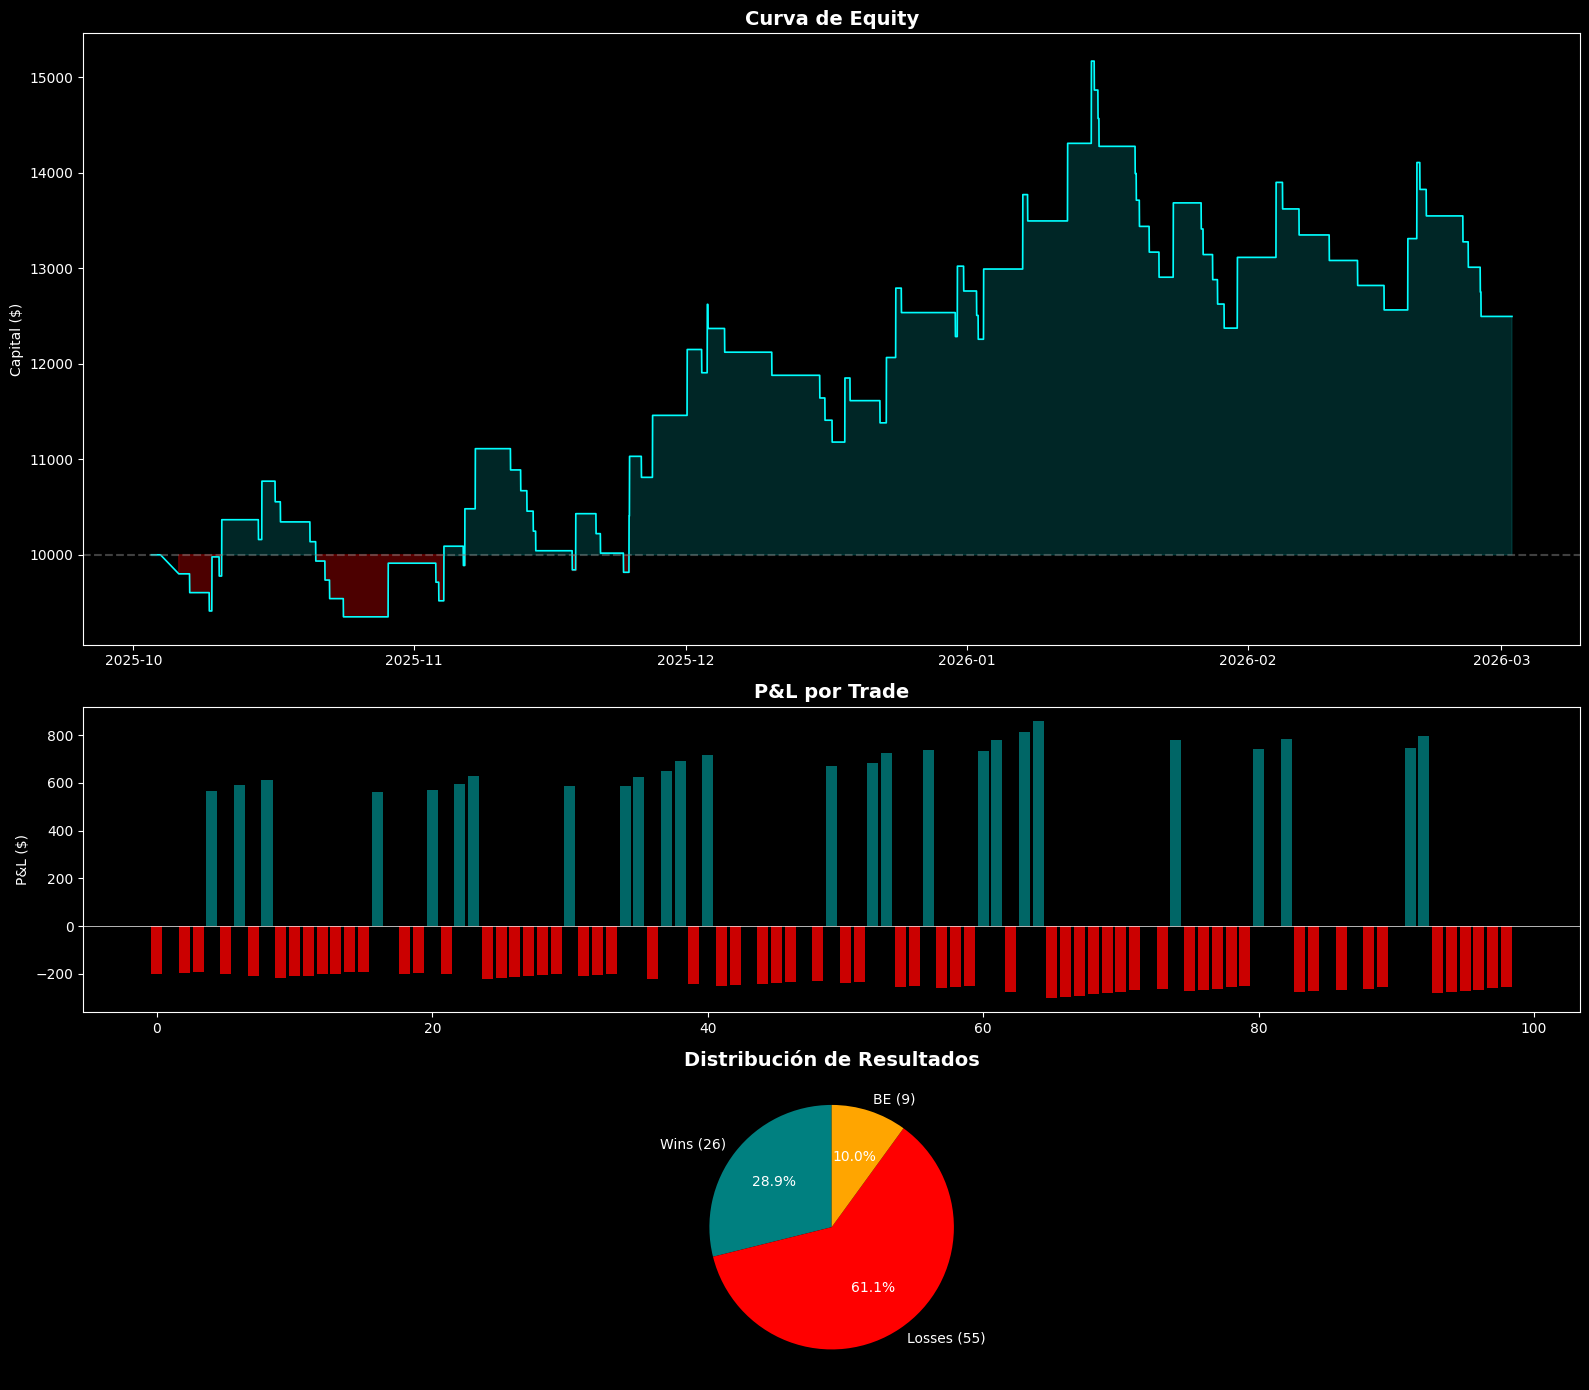

In [47]:
# ═══════════════════════════════════════════════════════════
# 7.1 — Curva de Equity
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(16, 14), gridspec_kw={'height_ratios': [2, 1, 1]})

# --- Equity ---
ax1 = axes[0]
ax1.plot(df.index[:len(equity)], equity, color='cyan', linewidth=1.2)
ax1.axhline(INITIAL_CAP, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Curva de Equity', fontsize=14, fontweight='bold')
ax1.set_ylabel('Capital ($)')
ax1.fill_between(df.index[:len(equity)], equity, INITIAL_CAP, 
                 where=[e >= INITIAL_CAP for e in equity], color='teal', alpha=0.3)
ax1.fill_between(df.index[:len(equity)], equity, INITIAL_CAP,
                 where=[e < INITIAL_CAP for e in equity], color='red', alpha=0.3)

# --- Distribución de P&L ---
ax2 = axes[1]
if len(trades) > 0:
    colors = ['teal' if t.pnl > 0 else 'red' for t in trades]
    ax2.bar(range(len(trades)), [t.pnl for t in trades], color=colors, alpha=0.8)
    ax2.axhline(0, color='white', linewidth=0.5)
ax2.set_title('P&L por Trade', fontsize=14, fontweight='bold')
ax2.set_ylabel('P&L ($)')

# --- Win rate pie ---
ax3 = axes[2]
if len(trades) > 0:
    be_count = sum(1 for t in trades if abs(t.pnl) < 0.01)
    win_count = len(wins)
    loss_count = len(losses) - be_count
    sizes = [win_count, loss_count, be_count]
    labels = [f'Wins ({win_count})', f'Losses ({loss_count})', f'BE ({be_count})']
    clrs = ['teal', 'red', 'orange']
    # Filter out zeros
    filtered = [(s,l,c) for s,l,c in zip(sizes,labels,clrs) if s > 0]
    if filtered:
        ax3.pie([f[0] for f in filtered], labels=[f[1] for f in filtered], 
                colors=[f[2] for f in filtered], autopct='%1.1f%%', startangle=90)
ax3.set_title('Distribución de Resultados', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

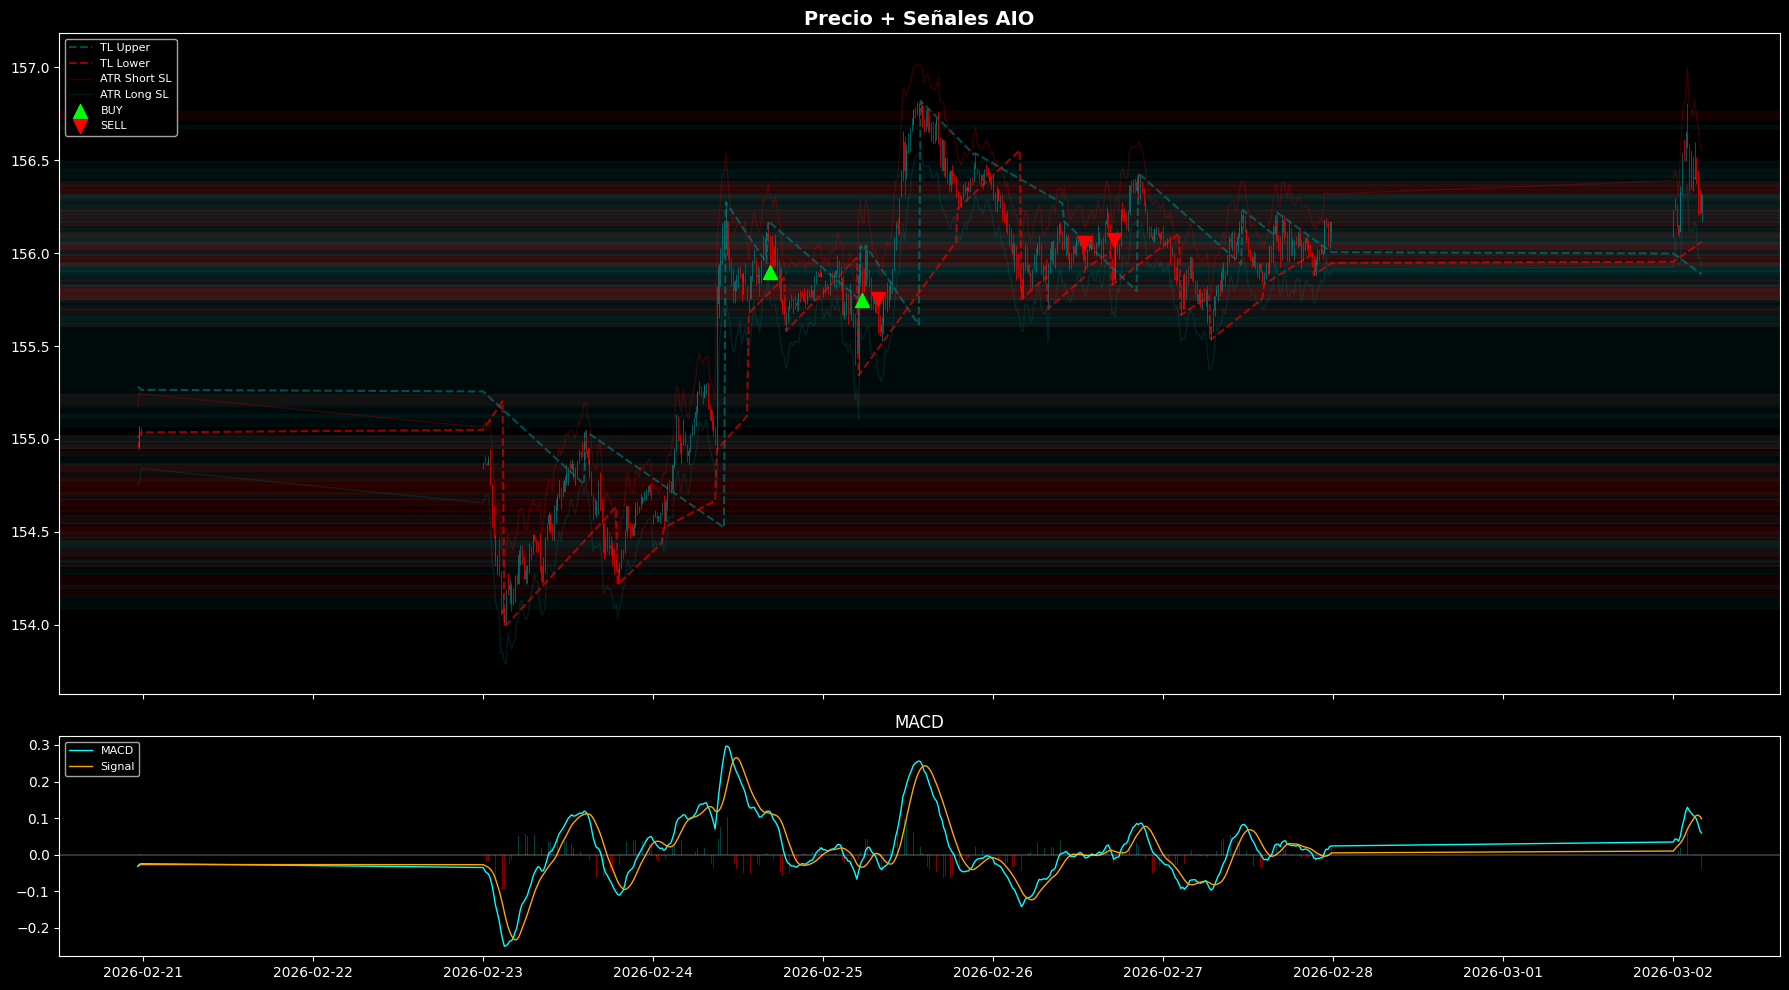

In [48]:
# ═══════════════════════════════════════════════════════════
# 7.2 — Gráfico de precio con señales (últimas N velas)
# ═══════════════════════════════════════════════════════════
SHOW_LAST = 500  # cuántas velas mostrar

sub = df.iloc[-SHOW_LAST:].copy()

fig, (ax_price, ax_macd) = plt.subplots(2, 1, figsize=(18, 10), 
                                         gridspec_kw={'height_ratios': [3, 1]},
                                         sharex=True)

# --- Precio y velas ---
up   = sub[sub['close'] >= sub['open']]
down = sub[sub['close'] < sub['open']]

ax_price.vlines(up.index, up['low'], up['high'], color='teal', linewidth=0.5)
ax_price.vlines(down.index, down['low'], down['high'], color='red', linewidth=0.5)
ax_price.bar(up.index, up['close']-up['open'], bottom=up['open'], color='teal', width=0.002, alpha=0.8)
ax_price.bar(down.index, down['open']-down['close'], bottom=down['close'], color='red', width=0.002, alpha=0.8)

# Trendlines
ax_price.plot(sub.index, sub['tl_upper'], color='teal', linestyle='--', alpha=0.6, label='TL Upper')
ax_price.plot(sub.index, sub['tl_lower'], color='red', linestyle='--', alpha=0.6, label='TL Lower')

# ATR SL
ax_price.plot(sub.index, sub['atr_short_sl'], color='red', alpha=0.2, linewidth=1, label='ATR Short SL')
ax_price.plot(sub.index, sub['atr_long_sl'], color='teal', alpha=0.2, linewidth=1, label='ATR Long SL')

# Señales
buys  = sub[sub['buy_signal']]
sells = sub[sub['sell_signal']]
ax_price.scatter(buys.index, buys['low']*0.9998, marker='^', color='lime', s=100, zorder=5, label='BUY')
ax_price.scatter(sells.index, sells['high']*1.0002, marker='v', color='red', s=100, zorder=5, label='SELL')

# FVGs
fvg_sub = sub[sub['fvg_type'] != 0]
for idx, row in fvg_sub.iterrows():
    c = 'teal' if row['fvg_type'] == 1 else 'red'
    ax_price.axhspan(row['fvg_btm'], row['fvg_top'], alpha=0.08, color=c)

ax_price.set_title('Precio + Señales AIO', fontsize=14, fontweight='bold')
ax_price.legend(loc='upper left', fontsize=8)

# --- MACD ---
ax_macd.plot(sub.index, sub['macd'], color='cyan', linewidth=1, label='MACD')
ax_macd.plot(sub.index, sub['macd_sig'], color='orange', linewidth=1, label='Signal')
colors_hist = ['teal' if v > 0 else 'red' for v in sub['macd_hist']]
ax_macd.bar(sub.index, sub['macd_hist'], color=colors_hist, alpha=0.5, width=0.002)
ax_macd.axhline(0, color='white', linewidth=0.3)
ax_macd.set_title('MACD', fontsize=12)
ax_macd.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Tabla de trades

In [49]:
# ═══════════════════════════════════════════════════════════
# Lista detallada de todos los trades
# ═══════════════════════════════════════════════════════════
if len(trades) > 0:
    trade_data = []
    for t in trades:
        trade_data.append({
            'Dirección': t.direction.upper(),
            'Entrada': f'{t.entry_px:.5f}',
            'SL': f'{t.sl:.5f}',
            'TP': f'{t.tp:.5f}',
            'Salida': f'{t.exit_px:.5f}' if t.exit_px else '-',
            'Lotes': f'{t.lots:.2f}',
            'P&L ($)': f'{t.pnl:.2f}',
            'BE Activo': '✓' if t.be_active else '',
            'Barra Entrada': t.bar_idx,
            'Barra Salida': t.exit_bar if t.exit_bar else '-',
            'Fecha Entrada': str(df.index[t.bar_idx]) if t.bar_idx < len(df) else '-',
        })
    
    trades_df = pd.DataFrame(trade_data)
    
    def color_pnl(val):
        try:
            v = float(val)
            return 'color: lime' if v > 0 else 'color: red' if v < 0 else ''
        except:
            return ''
    
    display(trades_df.style.applymap(color_pnl, subset=['P&L ($)']))
else:
    print('No hay trades para mostrar.')

,Dirección,Entrada,SL,TP,Salida,Lotes,P&L ($),BE Activo,Barra Entrada,Barra Salida,Fecha Entrada
0,SHORT,147.44700,147.56912,147.08065,147.56912,2.41,-199.43,,95,98,2025-10-03 23:15:00
1,LONG,150.21500,150.21500,150.45078,150.21500,3.75,0.00,✓,149,158,2025-10-06 12:45:00
2,LONG,150.48600,150.36077,150.86168,150.36077,2.36,-196.55,,208,214,2025-10-07 03:30:00
3,SHORT,152.53000,152.76860,151.81421,152.76860,1.23,-192.10,,406,422,2025-10-09 05:00:00
4,SHORT,152.80800,152.96680,152.33159,152.33159,1.81,566.06,,436,450,2025-10-09 12:30:00
5,LONG,152.82200,152.60038,153.48686,152.60038,1.38,-200.42,,524,527,2025-10-10 10:30:00
6,SHORT,152.72700,152.91991,152.14828,152.14828,1.55,589.57,,540,554,2025-10-10 14:30:00
7,LONG,152.03500,151.71377,152.99868,151.71377,0.98,-207.50,,743,751,2025-10-14 17:15:00
8,SHORT,151.75300,151.75300,151.37875,151.37875,2.47,610.65,✓,765,787,2025-10-14 22:45:00
9,LONG,151.28200,151.06355,151.93736,151.06355,1.49,-215.47,,916,928,2025-10-16 12:30:00


## 9. Optimización de parámetros (opcional)

Iniciando grid: 3 TFs × 5 RRs × 4 ATRs × 3 EntryTypes = 180 combinaciones

  Cargando USDJPY M15... 10000 velas
  Cargando USDJPY M30... 10000 velas
  Cargando USDJPY H1... 10000 velas

── Top 15 combinaciones ────────────────────────────


Timeframe,Entry Type,RR,ATR Mult,Trades,Win Rate,P. Factor,P&L Total ($),Capital Final ($),Retorno (%)
M30,fvg,4.000000,1.000000,106,31.1%,2.29,31603.090000,41603.090000,316.030000
M30,trigger_close,4.000000,1.000000,106,31.1%,2.29,31603.090000,41603.090000,316.030000
M30,next_open,4.000000,1.000000,106,31.1%,2.29,31603.090000,41603.090000,316.030000
M30,fvg,3.500000,1.000000,106,32.1%,2.06,22765.490000,32765.490000,227.650000
M30,trigger_close,3.500000,1.000000,106,32.1%,2.06,22765.490000,32765.490000,227.650000
M30,next_open,3.500000,1.000000,106,32.1%,2.06,22765.490000,32765.490000,227.650000
M30,next_open,2.500000,1.000000,112,42.9%,2.01,22221.880000,32221.880000,222.220000
M30,trigger_close,2.500000,1.000000,112,42.9%,2.01,22221.880000,32221.880000,222.220000
M30,fvg,2.500000,1.000000,112,42.9%,2.01,22221.880000,32221.880000,222.220000
M15,next_open,4.000000,1.000000,107,28.0%,2.01,21880.860000,31880.860000,218.810000


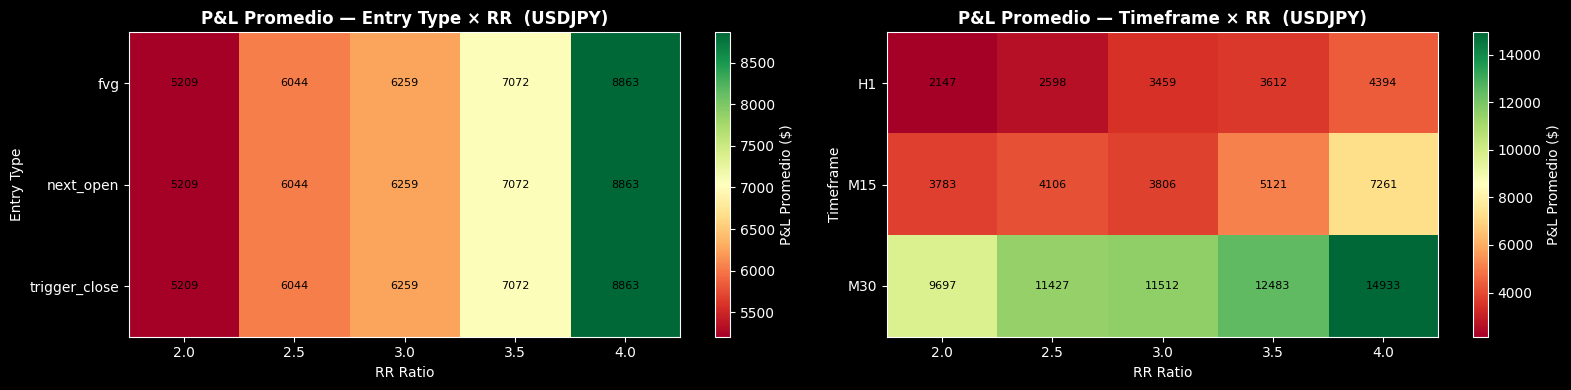


── Mejor combinación por Timeframe × Entry Type ────


Timeframe,Entry Type,RR,ATR Mult,Trades,Win Rate,P. Factor,P&L Total ($),Retorno (%)
M30,fvg,4.000000,1.000000,106,31.1%,2.29,31603.090000,316.030000
M30,trigger_close,4.000000,1.000000,106,31.1%,2.29,31603.090000,316.030000
M30,next_open,4.000000,1.000000,106,31.1%,2.29,31603.090000,316.030000
M15,next_open,4.000000,1.000000,107,28.0%,2.01,21880.860000,218.810000
M15,trigger_close,4.000000,1.000000,107,28.0%,2.01,21880.860000,218.810000
M15,fvg,4.000000,1.000000,107,28.0%,2.01,21880.860000,218.810000
H1,next_open,4.000000,1.000000,92,25.0%,1.46,7858.350000,78.580000
H1,fvg,4.000000,1.000000,92,25.0%,1.46,7858.350000,78.580000
H1,trigger_close,4.000000,1.000000,92,25.0%,1.46,7858.350000,78.580000


In [51]:

# ═══════════════════════════════════════════════════════════
# Grid search: Timeframe × RR × ATR Multiplier × Entry Type
# ═══════════════════════════════════════════════════════════
RUN_OPTIMIZATION = True

# ── Parámetros del grid ──────────────────────────────────
TF_RANGE         = ['M15', 'M30', 'H1']      # timeframes a comparar
RR_RANGE         = [2.0, 2.5, 3.0, 3.5, 4.0]
ATR_RANGE        = [1.0, 1.5, 2.0, 2.5]
ENTRY_TYPE_RANGE = ['fvg', 'trigger_close', 'next_open']
BARS_OPT         = 10000

_n_combos = len(TF_RANGE) * len(RR_RANGE) * len(ATR_RANGE) * len(ENTRY_TYPE_RANGE)

# ── Helpers ──────────────────────────────────────────────
def load_data_opt(symbol, tf_name, bars=10000):
    """Carga datos obligatoriamente desde MetaTrader 5.
    Reutiliza MT5_LOGIN / MT5_PASSWORD / MT5_SERVER / MT5_PATH del scope global."""
    import MetaTrader5 as mt5
    tf_map = {
        'M1':  mt5.TIMEFRAME_M1,  'M5':  mt5.TIMEFRAME_M5,
        'M15': mt5.TIMEFRAME_M15, 'M30': mt5.TIMEFRAME_M30,
        'H1':  mt5.TIMEFRAME_H1,  'H4':  mt5.TIMEFRAME_H4,
        'D1':  mt5.TIMEFRAME_D1,
    }
    if tf_name not in tf_map:
        raise ValueError(f'TF "{tf_name}" no válido. Opciones: {list(tf_map)}')

    _g = globals()
    init_kwargs = {}
    if _g.get('MT5_PATH'):   init_kwargs['path']     = _g['MT5_PATH']
    if _g.get('MT5_LOGIN'):
        init_kwargs['login']    = _g['MT5_LOGIN']
        init_kwargs['password'] = _g['MT5_PASSWORD']
        init_kwargs['server']   = _g['MT5_SERVER']

    if not mt5.initialize(**init_kwargs):
        code, msg = mt5.last_error()
        raise RuntimeError(
            f'MT5 init failed ({code}): {msg}\n'
            f'  → Rellena MT5_LOGIN / MT5_PASSWORD / MT5_SERVER en la celda de datos, o\n'
            f'  → Abre MetaTrader 5 manualmente e inicia sesión.'
        )

    info = mt5.symbol_info(symbol)
    if info is None:
        mt5.shutdown()
        raise RuntimeError(f'Símbolo "{symbol}" no encontrado en MT5.')
    if not info.visible:
        mt5.symbol_select(symbol, True)

    rates = mt5.copy_rates_from_pos(symbol, tf_map[tf_name], 0, bars)
    mt5.shutdown()

    if rates is None or len(rates) == 0:
        raise RuntimeError(f'MT5 no devolvió datos para {symbol} {tf_name}.')

    d = pd.DataFrame(rates)
    d['time'] = pd.to_datetime(d['time'], unit='s')
    d.set_index('time', inplace=True)
    d.rename(columns={'tick_volume': 'volume'}, inplace=True)
    return d


def compute_indicators_opt(d, tl_len, tl_mult, atr_sl_len, atr_sl_mult,
                            fast_len, slow_len, signal_len, fvg_gap,
                            entry_window, is_jpy):
    """Calcula todos los indicadores y señales sobre un DataFrame."""
    d = d.copy()

    # MACD
    d['ema_fast']  = d['close'].ewm(span=fast_len, adjust=False).mean()
    d['ema_slow']  = d['close'].ewm(span=slow_len, adjust=False).mean()
    d['macd']      = d['ema_fast'] - d['ema_slow']
    d['macd_sig']  = d['macd'].rolling(signal_len).mean()
    d['macd_above']= d['macd'] >= d['macd_sig']
    d['macd_cross']= d['macd_above'] != d['macd_above'].shift(1)
    d['cross_up']  = d['macd_cross'] & d['macd_above']
    d['cross_down']= d['macd_cross'] & ~d['macd_above']

    # TR / ATR
    d['tr'] = np.maximum(
        d['high'] - d['low'],
        np.maximum(np.abs(d['high'] - d['close'].shift(1)),
                   np.abs(d['low']  - d['close'].shift(1)))
    )
    d['atr_tl']   = d['tr'].rolling(tl_len).mean()
    d['tl_slope'] = d['atr_tl'] / tl_len * tl_mult

    # Pivots
    ph = pd.Series(np.nan, index=d.index)
    pl = pd.Series(np.nan, index=d.index)
    for i in range(tl_len, len(d) - tl_len):
        wh = d['high'].iloc[i-tl_len:i+tl_len+1]
        wl = d['low'].iloc[i-tl_len:i+tl_len+1]
        if d['high'].iloc[i] == wh.max(): ph.iloc[i] = d['high'].iloc[i]
        if d['low'].iloc[i]  == wl.min(): pl.iloc[i] = d['low'].iloc[i]
    d['pivot_high'] = ph
    d['pivot_low']  = pl

    # Trendlines
    n = len(d)
    tl_upper = np.zeros(n); tl_lower = np.zeros(n)
    slope_ph = np.zeros(n); slope_pl = np.zeros(n)
    tl_upos  = np.zeros(n, dtype=int); tl_dnos = np.zeros(n, dtype=int)
    tl_s = d['tl_slope'].values
    ph_v = d['pivot_high'].values; pl_v = d['pivot_low'].values
    cl_v = d['close'].values
    for i in range(1, n):
        s = tl_s[i] if not np.isnan(tl_s[i]) else 0
        if not np.isnan(ph_v[i]):
            slope_ph[i] = s; tl_upper[i] = ph_v[i]; tl_upos[i] = 0
        else:
            slope_ph[i] = slope_ph[i-1]
            tl_upper[i] = tl_upper[i-1] - slope_ph[i]
            tl_upos[i]  = 1 if cl_v[i] > tl_upper[i] - slope_ph[i]*tl_len else tl_upos[i-1]
        if not np.isnan(pl_v[i]):
            slope_pl[i] = s; tl_lower[i] = pl_v[i]; tl_dnos[i] = 0
        else:
            slope_pl[i] = slope_pl[i-1]
            tl_lower[i] = tl_lower[i-1] + slope_pl[i]
            tl_dnos[i]  = 1 if cl_v[i] < tl_lower[i] + slope_pl[i]*tl_len else tl_dnos[i-1]
    d['tl_upos'] = tl_upos; d['tl_dnos'] = tl_dnos
    d['tl_break_up'] = (d['tl_upos'] > d['tl_upos'].shift(1)).fillna(False)
    d['tl_break_dn'] = (d['tl_dnos'] > d['tl_dnos'].shift(1)).fillna(False)

    # FVG
    fvg_type = np.zeros(n); fvg_top = np.full(n, np.nan); fvg_btm = np.full(n, np.nan)
    h = d['high'].values; l = d['low'].values; c = d['close'].values
    for i in range(2, n):
        if l[i] > h[i-2] and c[i-1] > h[i-2] and (l[i]-h[i-2])/h[i-2]*100 > fvg_gap:
            fvg_type[i]=1;  fvg_top[i]=l[i];    fvg_btm[i]=h[i-2]
        elif h[i] < l[i-2] and c[i-1] < l[i-2] and (l[i-2]-h[i])/h[i]*100 > fvg_gap:
            fvg_type[i]=-1; fvg_top[i]=l[i-2];  fvg_btm[i]=h[i]
    d['fvg_type'] = fvg_type; d['fvg_top'] = fvg_top; d['fvg_btm'] = fvg_btm

    # ATR SL
    d['atr_sl']       = d['tr'].ewm(alpha=1/atr_sl_len, adjust=False).mean() * atr_sl_mult
    d['atr_short_sl'] = d['high'] + d['atr_sl']
    d['atr_long_sl']  = d['low']  - d['atr_sl']

    # Señales de confluencia
    tbu = d['tl_break_up'].values; tbd = d['tl_break_dn'].values
    cup = d['cross_up'].values;    cdn = d['cross_down'].values
    bars_tl_up = np.full(n, 999); bars_tl_dn = np.full(n, 999)
    bars_mc_up = np.full(n, 999); bars_mc_dn = np.full(n, 999)
    for i in range(1, n):
        bars_tl_up[i] = 0 if tbu[i] else min(bars_tl_up[i-1]+1, 999)
        bars_tl_dn[i] = 0 if tbd[i] else min(bars_tl_dn[i-1]+1, 999)
        bars_mc_up[i] = 0 if cup[i] else min(bars_mc_up[i-1]+1, 999)
        bars_mc_dn[i] = 0 if cdn[i] else min(bars_mc_dn[i-1]+1, 999)
    d['sell_signal'] = ((tbd & (bars_mc_dn<=entry_window)) |
                        (cdn & (bars_tl_dn<=entry_window) & (bars_tl_dn>0)))
    d['buy_signal']  = ((tbu & (bars_mc_up<=entry_window)) |
                        (cup & (bars_tl_up<=entry_window) & (bars_tl_up>0)))

    # Último FVG
    lbt = np.full(n, np.nan); lbb = np.full(n, np.nan)
    lrt = np.full(n, np.nan); lrb = np.full(n, np.nan)
    for i in range(1, n):
        lbt[i] = fvg_top[i] if fvg_type[i]==1  else lbt[i-1]
        lbb[i] = fvg_btm[i] if fvg_type[i]==1  else lbb[i-1]
        lrt[i] = fvg_top[i] if fvg_type[i]==-1 else lrt[i-1]
        lrb[i] = fvg_btm[i] if fvg_type[i]==-1 else lrb[i-1]
    d['last_bull_top'] = lbt; d['last_bull_btm'] = lbb
    d['last_bear_top'] = lrt; d['last_bear_btm'] = lrb
    return d


# ── Grid search ──────────────────────────────────────────
if RUN_OPTIMIZATION:
    print(f'Iniciando grid: {len(TF_RANGE)} TFs × {len(RR_RANGE)} RRs × '
          f'{len(ATR_RANGE)} ATRs × {len(ENTRY_TYPE_RANGE)} EntryTypes '
          f'= {_n_combos} combinaciones\n')

    results    = []
    data_cache = {}   # evita re-descargar el mismo TF

    for tf in TF_RANGE:
        if tf not in data_cache:
            print(f'  Cargando {SYMBOL} {tf}...', end=' ')
            data_cache[tf] = load_data_opt(SYMBOL, tf, BARS_OPT)
            print(f'{len(data_cache[tf])} velas')

        for atr_m in ATR_RANGE:
            # Los indicadores no dependen de RR ni EntryType → computar una vez por (TF, ATR)
            d_ind = compute_indicators_opt(
                data_cache[tf],
                tl_len=TL_LENGTH, tl_mult=TL_MULT,
                atr_sl_len=ATR_SL_LEN, atr_sl_mult=atr_m,
                fast_len=FAST_LEN, slow_len=SLOW_LEN, signal_len=SIGNAL_LEN,
                fvg_gap=FVG_GAP_PCT, entry_window=ENTRY_WINDOW,
                is_jpy=SYMBOL.endswith('JPY')
            )

            for rr in RR_RANGE:
                for et in ENTRY_TYPE_RANGE:

                    # Monkey-patch globals para que run_backtest los lea
                    _rr_bak = globals().get('RR_RATIO')
                    _et_bak = globals().get('ENTRY_TYPE')
                    globals()['RR_RATIO']   = rr
                    globals()['ENTRY_TYPE'] = et

                    t, eq = run_backtest(d_ind, INITIAL_CAP, RISK_PCT)

                    globals()['RR_RATIO']   = _rr_bak
                    globals()['ENTRY_TYPE'] = _et_bak

                    pnls       = [tr.pnl for tr in t]
                    total      = sum(pnls) if pnls else 0
                    wr         = sum(1 for p in pnls if p > 0) / len(pnls)*100 if pnls else 0
                    wins_sum   = sum(p for p in pnls if p > 0)
                    losses_sum = abs(sum(p for p in pnls if p < 0))
                    pf         = wins_sum / losses_sum if losses_sum > 0 else float('inf')

                    results.append({
                        'Timeframe':         tf,
                        'Entry Type':        et,
                        'RR':                rr,
                        'ATR Mult':          atr_m,
                        'Trades':            len(t),
                        'Win Rate':          f'{wr:.1f}%',
                        'P. Factor':         f'{pf:.2f}',
                        'P&L Total ($)':     round(total, 2),
                        'Capital Final ($)': round(eq[-1], 2),
                        'Retorno (%)':       round((eq[-1]/INITIAL_CAP-1)*100, 2),
                    })

    opt_df = pd.DataFrame(results)
    opt_df['P&L Total ($)'] = pd.to_numeric(opt_df['P&L Total ($)'])
    opt_df_sorted = opt_df.sort_values('P&L Total ($)', ascending=False).reset_index(drop=True)

    # ── Top 15 combinaciones ──────────────────────────────
    print('\n── Top 15 combinaciones ────────────────────────────')
    display(opt_df_sorted.head(15).style
            .background_gradient(subset=['P&L Total ($)', 'Retorno (%)'], cmap='RdYlGn')
            .hide(axis='index'))

    # ── Heatmap: P&L promedio por Entry Type × RR ─────────
    pivot_et = opt_df.groupby(['Entry Type', 'RR'])['P&L Total ($)'].mean().unstack('RR')
    fig, axes_g = plt.subplots(1, 2, figsize=(16, 4))

    # subplot 1: Entry Type × RR
    ax_et = axes_g[0]
    im1 = ax_et.imshow(pivot_et.values, aspect='auto', cmap='RdYlGn')
    ax_et.set_xticks(range(len(pivot_et.columns))); ax_et.set_xticklabels(pivot_et.columns)
    ax_et.set_yticks(range(len(pivot_et.index)));   ax_et.set_yticklabels(pivot_et.index)
    ax_et.set_xlabel('RR Ratio'); ax_et.set_ylabel('Entry Type')
    ax_et.set_title(f'P&L Promedio — Entry Type × RR  ({SYMBOL})', fontweight='bold')
    plt.colorbar(im1, ax=ax_et, label='P&L Promedio ($)')
    for r in range(len(pivot_et.index)):
        for c_idx in range(len(pivot_et.columns)):
            ax_et.text(c_idx, r, f'{pivot_et.values[r,c_idx]:.0f}',
                       ha='center', va='center', fontsize=8, color='black')

    # subplot 2: Timeframe × RR (promedio sobre ATR Mult y Entry Type)
    pivot_tf = opt_df.groupby(['Timeframe', 'RR'])['P&L Total ($)'].mean().unstack('RR')
    ax_tf = axes_g[1]
    im2 = ax_tf.imshow(pivot_tf.values, aspect='auto', cmap='RdYlGn')
    ax_tf.set_xticks(range(len(pivot_tf.columns))); ax_tf.set_xticklabels(pivot_tf.columns)
    ax_tf.set_yticks(range(len(pivot_tf.index)));   ax_tf.set_yticklabels(pivot_tf.index)
    ax_tf.set_xlabel('RR Ratio'); ax_tf.set_ylabel('Timeframe')
    ax_tf.set_title(f'P&L Promedio — Timeframe × RR  ({SYMBOL})', fontweight='bold')
    plt.colorbar(im2, ax=ax_tf, label='P&L Promedio ($)')
    for r in range(len(pivot_tf.index)):
        for c_idx in range(len(pivot_tf.columns)):
            ax_tf.text(c_idx, r, f'{pivot_tf.values[r,c_idx]:.0f}',
                       ha='center', va='center', fontsize=8, color='black')

    plt.tight_layout(); plt.show()

    # ── Mejor combinación por Timeframe × Entry Type ──────
    print('\n── Mejor combinación por Timeframe × Entry Type ────')
    best_per_tf_et = (opt_df_sorted
                      .groupby(['Timeframe', 'Entry Type'], sort=False)
                      .first()
                      .reset_index())
    display(best_per_tf_et[['Timeframe','Entry Type','RR','ATR Mult','Trades',
                             'Win Rate','P. Factor','P&L Total ($)','Retorno (%)']
                           ].style
              .background_gradient(subset=['P&L Total ($)'], cmap='RdYlGn')
              .hide(axis='index'))

else:
    print('Optimización desactivada. Cambia RUN_OPTIMIZATION = True para ejecutar.')
